# Генератор пользовательских данных для подсчета клеток крови — HT_4

В рамках домашнего задания 4, на основе реализованного генератора, выполнить тренировку нейронной сети resnet для решения задачи подсчета количества клеток на изображении.

Математематическая постановка может решать в виде решения задачи классификации. Номер класса- количество клеток на изображения.
Рекомендуется применять BCELoss.
В качестве target вероятностной метрики использовать распределение в терминах uncertancy, близкое к нормальному.
Пример target-вероятностного вектора для задачи с максимальным количеством клеток равным 10.

Пример для изображения с количеством клеток 7.
[0,0,0,0,0.1,0.5,1.0,0.5,0.1,0]

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from typing import Tuple, List
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import torch
import torchsummary
import torch.nn as nn
from torchvision import models, transforms
from scipy.stats import norm
from tqdm import tqdm

## 1. Загрузка и подготовка данных

In [30]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MAX_CELLS = 9
BATCH_SIZE = 32
EPOCHS = 5
LR = 0.0005

TOTAL_DATA = 1000
TRAIN_RATIO = 0.8
VAL_RATIO = 0.2

TRAIN_SIZE = int(TOTAL_DATA * TRAIN_RATIO)
VAL_SIZE   = int(TOTAL_DATA * VAL_RATIO)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

DATA_DIR = 'BCCD Dataset with mask/train'
IMAGES_DIR = os.path.join(DATA_DIR, 'original')
MASKS_DIR = os.path.join(DATA_DIR, 'mask')

BACKGROUND_PATCHES_DIR = 'background_patches'
CELL_PATCHES_DIR = 'cell_patches'
os.makedirs(BACKGROUND_PATCHES_DIR, exist_ok=True)
os.makedirs(CELL_PATCHES_DIR, exist_ok=True)

Device: cuda


In [31]:
def load_blood_cell_dataset(images_dir, masks_dir, max_images=1000):
    images = []
    masks = []
    
    for filename in os.listdir(images_dir):
        if len(images) >= max_images:
            break
            
        img_path = os.path.join(images_dir, filename)
        mask_path = os.path.join(masks_dir, filename)
        
        if os.path.exists(mask_path):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            if img is not None and mask is not None:
                images.append(img)
                masks.append(mask)
    
    return images, masks

In [32]:
def extract_patches(images, masks, patch_size=(128, 128), n_patches=100):
    background_patches = []
    cell_patches = []
    
    for img, mask in zip(images, masks):
        h, w = img.shape[:2]
        
        for _ in range(n_patches // 2):
            x = random.randint(0, w - patch_size[1])
            y = random.randint(0, h - patch_size[0])
            
            patch = img[y:y+patch_size[0], x:x+patch_size[1]]
            mask_patch = mask[y:y+patch_size[0], x:x+patch_size[1]]
            
            if np.count_nonzero(mask_patch) < patch_size[0] * patch_size[1] * 0.05:
                background_patches.append(patch)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            x, y, w_cell, h_cell = cv2.boundingRect(contour)
            
            if w_cell > 20 and h_cell > 20:
                pad = 10
                x1 = max(0, x - pad)
                y1 = max(0, y - pad)
                x2 = min(img.shape[1], x + w_cell + pad)
                y2 = min(img.shape[0], y + h_cell + pad)
                
                cell_patch = img[y1:y2, x1:x2]
                cell_mask = mask[y1:y2, x1:x2]
                
                cell_only = cv2.bitwise_and(cell_patch, cell_patch, mask=cell_mask)
                if cell_only.size > 0:
                    cell_patches.append(cell_only)
    
    return background_patches, cell_patches

In [33]:
def save_patches(background_patches, cell_patches, bg_dir, cell_dir, max_save=50):
    for i, patch in enumerate(background_patches[:max_save]):
        cv2.imwrite(os.path.join(bg_dir, f'bg_{i}.png'), patch)
    
    for i, patch in enumerate(cell_patches[:max_save]):
        cv2.imwrite(os.path.join(cell_dir, f'cell_{i}.png'), patch)
    
    print(f"Сохранено {len(background_patches)} патчей фона и {len(cell_patches)} патчей клеток")

In [34]:
try:
    images, masks = load_blood_cell_dataset(IMAGES_DIR, MASKS_DIR, 200)
    print(f"Загружено {len(images)} изображений")
    
    bg_patches, cell_patches = extract_patches(images, masks)
    save_patches(bg_patches, cell_patches, BACKGROUND_PATCHES_DIR, CELL_PATCHES_DIR)
    
except FileNotFoundError:
    print("Набор данных не найден. Используем синтетические данные.")
    bg_patches, cell_patches = [], []

Загружено 200 изображений
Сохранено 2265 патчей фона и 14454 патчей клеток


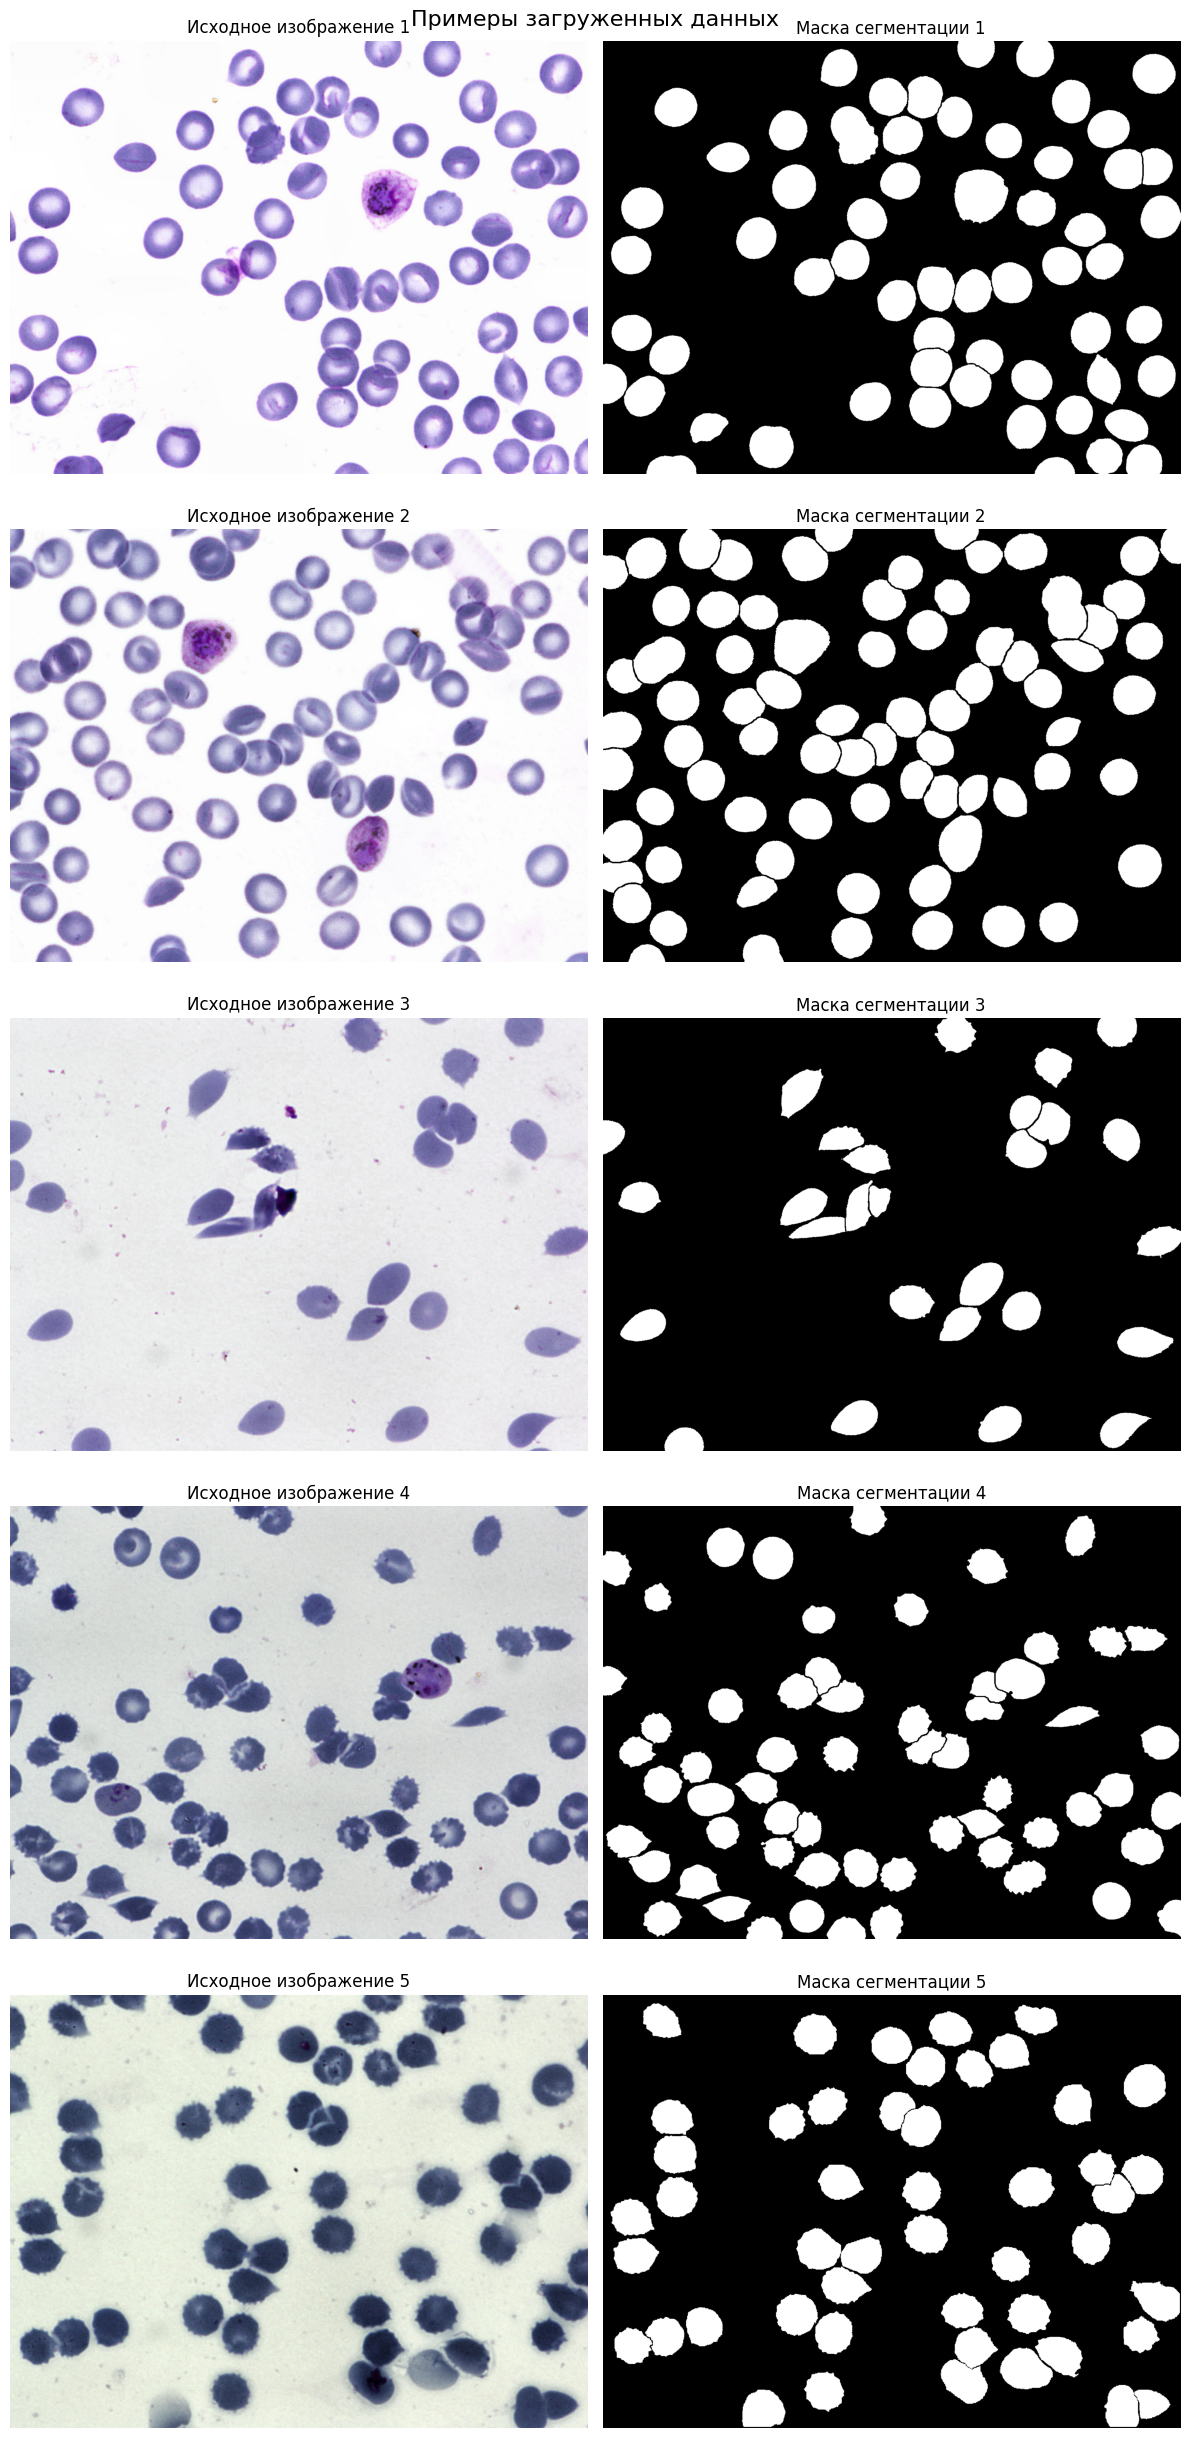

In [35]:
fig, axes = plt.subplots(5, 2, figsize=(12, 25))
fig.suptitle("Примеры загруженных данных", fontsize=16)

for i in range(5):
    axes[i, 0].imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Исходное изображение {i+1}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(masks[i], cmap='gray')
    axes[i, 1].set_title(f"Маска сегментации {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

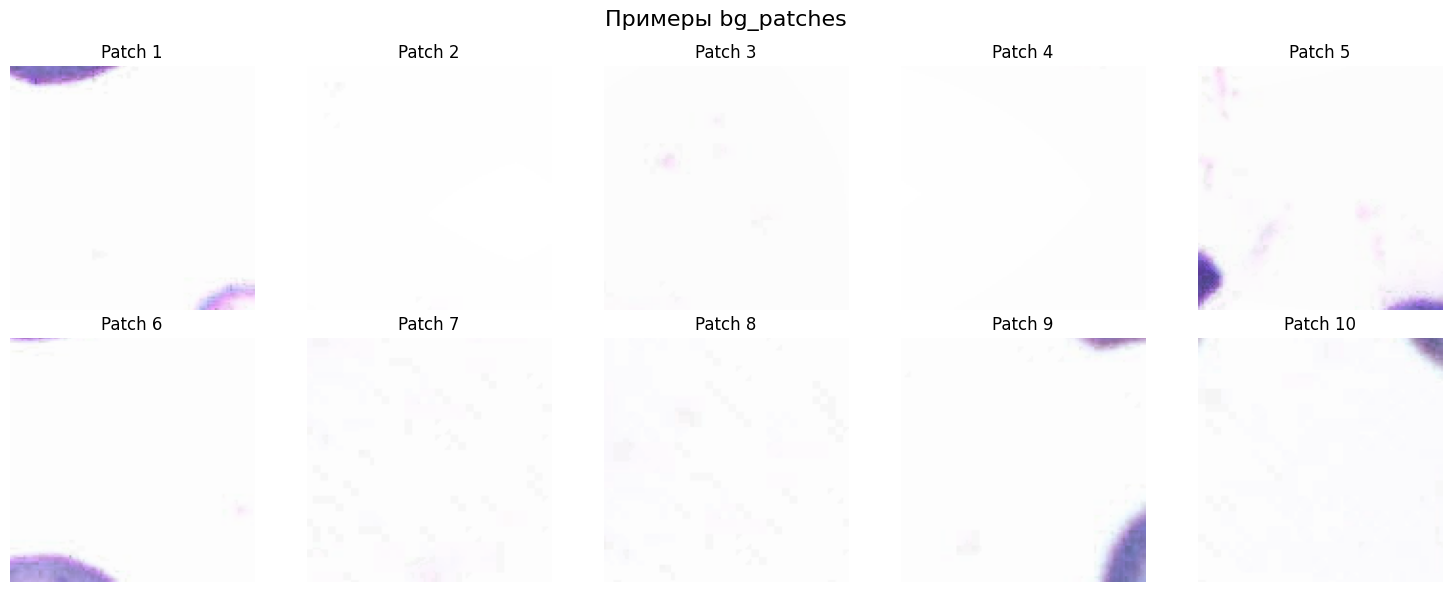

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры bg_patches", fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(cv2.cvtColor(bg_patches[i], cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f"Patch {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 2. Реализация Dataset класса

In [37]:
class BloodCellsDataset(Dataset):
    def __init__(
        self,
        img_size: Tuple[int, int] = (224, 224),
        dataset_size: int = 200,
        bg_patches: List = None,
        cell_patches: List = None,
        p_background_solid: float = 0.3,
        p_cell_artificial: float = 0.3,
        min_cells_count: int = 1,
        max_cells_count: int = 9,
        min_cell_coverage: float = 0.3,
        sigma: float = 1.2,
        seed: int = 42
    ):
        random.seed(seed)
        np.random.seed(seed)
        
        self.img_size = img_size
        self.dataset_size = dataset_size
        self.bg_patches = bg_patches if bg_patches else []
        self.cell_patches = cell_patches if cell_patches else []
        self.p_background_solid = p_background_solid
        self.p_cell_artificial = p_cell_artificial
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        self.num_classes = max_cells_count + 1
        self.min_cell_coverage = min_cell_coverage
        self.sigma = sigma
        
        self.normalize = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    
    def __len__(self):
        return self.dataset_size
    
    def _create_soft_target(self, true_count: int) -> torch.Tensor:
        target = np.zeros(self.num_classes, dtype=np.float32)

        if true_count >= self.num_classes:
            target[-1] = 1.0
        else:
            x = np.arange(self.num_classes)
            pdf = norm.pdf(x, loc=true_count, scale=self.sigma)
            target = pdf / pdf.max()
        
        return torch.tensor(target, dtype=torch.float32)
    
    def __getitem__(self, item):
        cells_count = random.randint(self.min_cells_count, self.max_cells_count)
        
        clean_img = self._select_background()

        cells_img = np.zeros((clean_img.shape[0], clean_img.shape[1], 3), dtype=np.uint8)
        temp_img = np.zeros((clean_img.shape[0], clean_img.shape[1], 3), dtype=np.uint8)
        temp_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), dtype=np.uint8)

        cells_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), dtype=np.uint8)
        temp_mask = cells_mask.copy()
        cells_img = np.zeros_like(clean_img)
        temp_img = np.zeros_like(cells_img)
        
        actual_cells_count = 0

        for i in range(cells_count):
            for _max_attempts in range(2000):
                temp_mask.fill(0)
                temp_img.fill(0)
    
                x = random.randint(0, clean_img.shape[1] - 10)
                y = random.randint(0, clean_img.shape[0] - 10)
                
                use_artificial_cell = random.random() < self.p_cell_artificial
                
                if use_artificial_cell and len(self.cell_patches) > 0:
                    patch = random.choice(self.cell_patches)
                    rad = random.randint(max(3, patch.shape[0]//12), patch.shape[0]//6)
                    color = self._get_cell_color()
                    
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    temp_img = temp_img.astype(np.uint8)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=color, thickness=-1)
                elif len(self.cell_patches) > 0:
                    cell_patch = random.choice(self.cell_patches)
                    cell_patch = cv2.resize(cell_patch, (random.randint(15, 35), random.randint(15, 35)))
                    
                    h_patch, w_patch = cell_patch.shape[:2]
                    x1 = max(0, min(x - w_patch//2, clean_img.shape[1] - w_patch))
                    y1 = max(0, min(y - h_patch//2, clean_img.shape[0] - h_patch))
                    
                    temp_mask[y1:y1+h_patch, x1:x1+w_patch] = 255
                    temp_img[y1:y1+h_patch, x1:x1+w_patch] = cell_patch
                else:
                    rad = random.randint(8, 18)
                    color = self._get_cell_color()
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    temp_img = temp_img.astype(np.uint8)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=color, thickness=-1)
                
                temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                coverage = np.count_nonzero(temp_mask_without) / max(1, np.count_nonzero(temp_mask))
                
                if coverage >= self.min_cell_coverage:
                    cells_img = self._add_image_with_mask(cells_img, temp_img, temp_mask_without)
                    cells_mask = self._add_image_with_mask(cells_mask, temp_mask, temp_mask_without)
                    actual_cells_count += 1
                    break
            
            if actual_cells_count >= cells_count:
                break
        
        #clean_img = self._seamless_clone(clean_img, cells_img, cells_mask)
        clean_img = self._add_image_with_mask(clean_img, cells_img, cells_mask)
        
        image = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        image = self.normalize(image)
        
        target = self._create_soft_target(actual_cells_count)
        
        return image, target, actual_cells_count
        
    def _select_background(self):
        if random.random() < self.p_background_solid or len(self.bg_patches) == 0:
            color = [random.randint(150, 220) for _ in range(3)]
            return np.ones((self.img_size[0], self.img_size[1], 3), dtype=np.uint8) * color
        else:
            bg = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            patch_size = 128
            
            for i in range(0, self.img_size[0], patch_size):
                for j in range(0, self.img_size[1], patch_size):
                    if len(self.bg_patches) > 0:
                        patch = random.choice(self.bg_patches)
                        patch = cv2.resize(patch, (patch_size, patch_size))
                    else:
                        patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 220
                    
                    h_end = min(i + patch_size, self.img_size[0])
                    w_end = min(j + patch_size, self.img_size[1])
                    bg[i:h_end, j:w_end] = patch[:h_end-i, :w_end-j]
            
            return bg
    
    def _get_cell_color(self):
        return (
            random.randint(150, 200),
            random.randint(100, 200),
            random.randint(50, 150)
        )
    
    def _seamless_clone(self, dst, src, mask):

        dst = dst.astype(np.uint8)
        src = src.astype(np.uint8)
        mask = mask.astype(np.uint8)

        if np.count_nonzero(mask) == 0:
            return dst

        M = cv2.moments(mask)
        if M["m00"] != 0:
            center_x = int(M["m10"] / M["m00"])
            center_y = int(M["m01"] / M["m00"])
            center = (center_x, center_y)
        else:
            center = (dst.shape[1] // 2, dst.shape[0] // 2)

        try:
            result = cv2.seamlessClone(src, dst, mask, center, cv2.NORMAL_CLONE)
            return result
        except:
            return self._add_image_with_mask(dst, src, mask)
    
    def _add_image_with_mask(self, a, b, mask):
        a = a.astype(np.uint8)
        b = b.astype(np.uint8)
        mask = mask.astype(np.uint8)

        result = a.copy()
        result[mask > 0] = b[mask > 0]
    
        return result

        #a1 = cv2.bitwise_and(a, a, mask=cv2.bitwise_not(mask))
        #b1 = cv2.bitwise_and(b, b, mask=mask)
        #return cv2.add(a1, b1)

In [38]:
dataset = BloodCellsDataset(
    img_size=(224, 224),
    dataset_size=TOTAL_DATA,
    bg_patches=bg_patches,
    cell_patches=cell_patches,
    min_cells_count=1,
    max_cells_count=MAX_CELLS,
    sigma=1.2
)

train_size = int(0.8 * len(dataset))
test_size   = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


print(f"Датасет создан: {len(dataset)} изображений")
print(f"Тренировочный датасет: {len(train_dataset)} изображений")
print(f"Валидационный датасет: {len(test_dataset)} изображений")

Датасет создан: 1000 изображений
Тренировочный датасет: 800 изображений
Валидационный датасет: 200 изображений


Пример изображения из тренировочного датасета
Размер изображения: 224 x 224 x 3
Количкство клеток: 2
Вероятностный вектор : [0.25 0.71 1.   0.71 0.25 0.04 0.   0.   0.   0.  ]


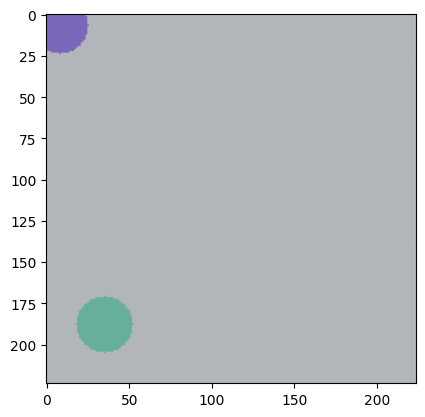

In [39]:
image, target_vec, cells_count = train_dataset[random.randint(0, len(train_dataset))]

print("Пример изображения из тренировочного датасета")
print(f"Размер изображения: {image.shape[2]} x {image.shape[1]} x {image.shape[0]}")
print(f"Количкство клеток: {cells_count}")
print(f"Вероятностный вектор : {np.round(target_vec.numpy(), 2)}")

img_show = image.clone()
img_show = img_show * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
img_show = np.clip(img_show.numpy().transpose(1, 2, 0), 0, 1) 

plt.imshow(img_show)
plt.show()

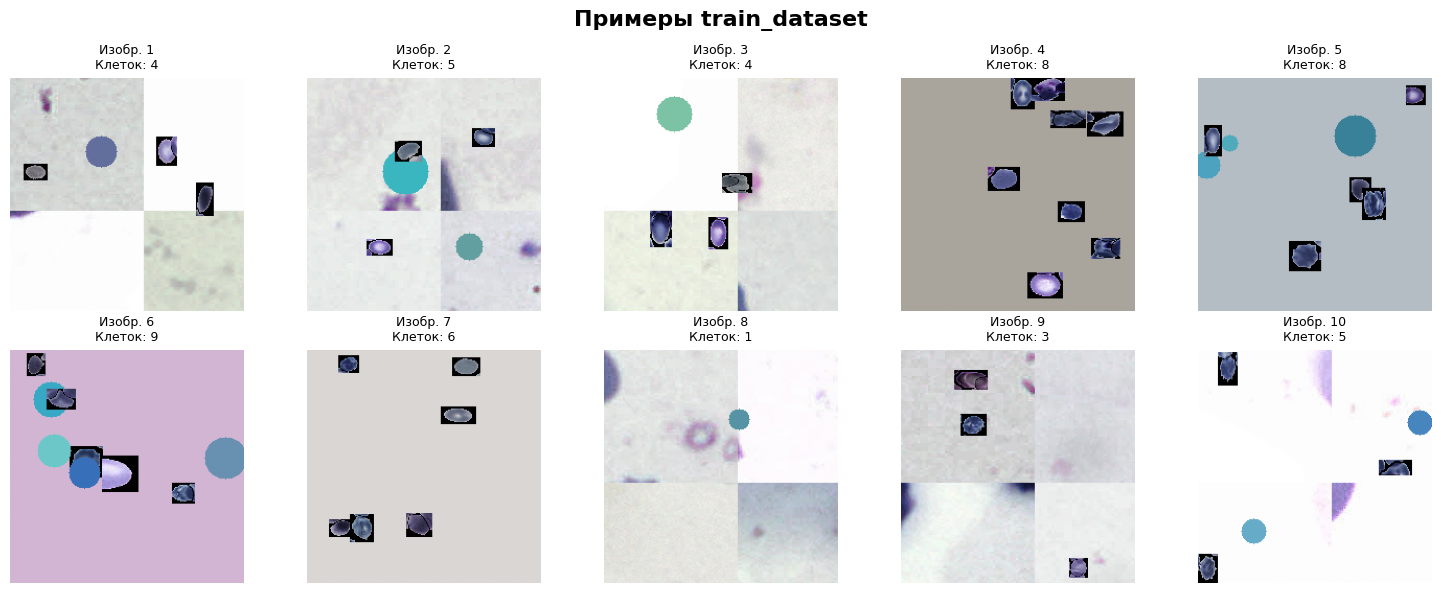

Форма одного изображения: torch.Size([3, 224, 224])
Тип данных: torch.float32
Всего изображений в датасете: 800


In [40]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры train_dataset", fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    
    image, target_vec, cells_count = train_dataset[i]

    img_show = image.clone()
    img_show = img_show * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img_show = np.clip(img_show.numpy().transpose(1, 2, 0), 0, 1) 

    axes[row, col].imshow(img_show)
    axes[row, col].set_title(f"Изобр. {i+1}\nКлеток: {cells_count}", fontsize=9)
    axes[row, col].axis('off')

    for spine in axes[row, col].spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

clean_img, _, _ = train_dataset[0]
print(f"Форма одного изображения: {clean_img.shape}")
print(f"Тип данных: {clean_img.dtype}")
print(f"Всего изображений в датасете: {len(train_dataset)}")

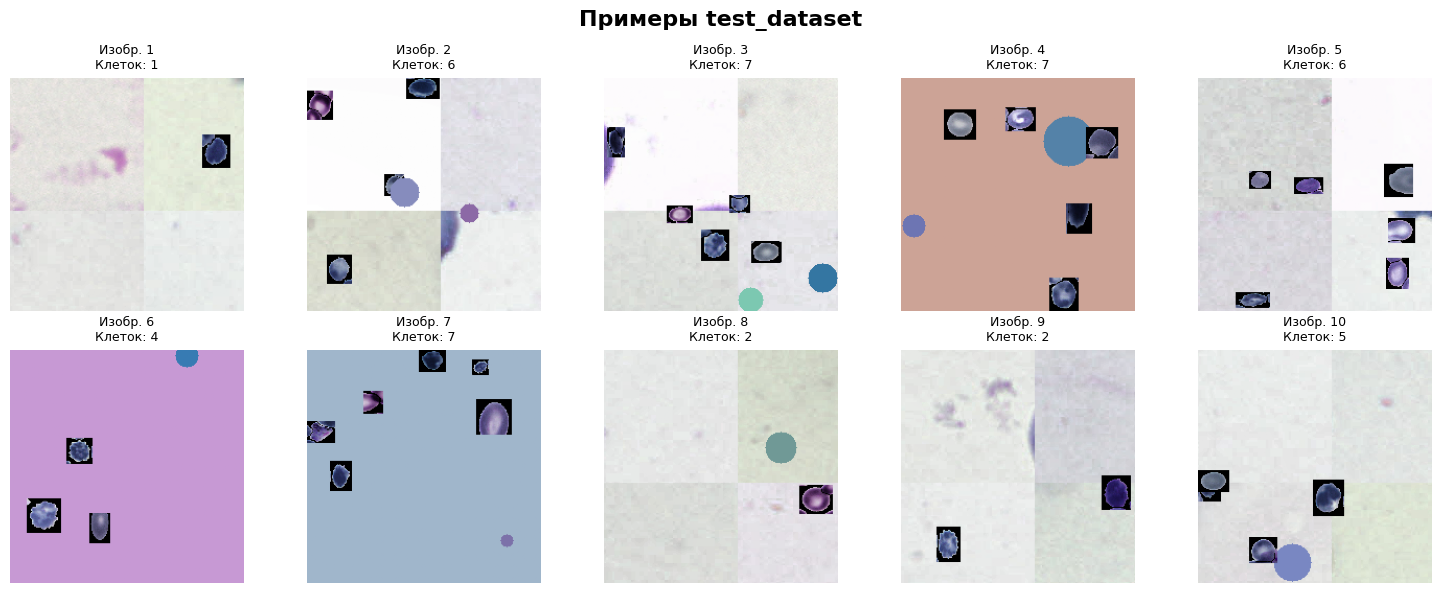

Форма одного изображения: torch.Size([3, 224, 224])
Тип данных: torch.float32
Диапазон значений: [-2.1179039478302, 2.465708017349243]
Всего изображений в датасете: 800


In [41]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры test_dataset", fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    
    image, target_vec, cells_count = test_dataset[i]

    img_show = image.clone()
    img_show = img_show * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img_show = np.clip(img_show.numpy().transpose(1, 2, 0), 0, 1) 

    axes[row, col].imshow(img_show)
    axes[row, col].set_title(f"Изобр. {i+1}\nКлеток: {cells_count}", fontsize=9)
    axes[row, col].axis('off')

    for spine in axes[row, col].spines.values():
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

clean_img, _, _ = test_dataset[0]
print(f"Форма одного изображения: {clean_img.shape}")
print(f"Тип данных: {clean_img.dtype}")
print(f"Диапазон значений: [{clean_img.min()}, {clean_img.max()}]")
print(f"Всего изображений в датасете: {len(train_dataset)}")

## 3. Обучение

In [42]:
train_dataset_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_dataset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [43]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, MAX_CELLS + 1)
model = model.to(DEVICE)
torchsummary.summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [44]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [45]:
def train_step(model, loss_function, optimizer, image, target):
    model.train()
    optimizer.zero_grad()
    prediction = model(image)
    loss = loss_function(prediction, target)
    loss.backward()
    optimizer.step()
    return loss.item()

In [46]:
@torch.no_grad()
def accuracy(model, image, true_counts):
    model.eval()
    prediction = model(image)
    _, argmaxes = prediction.max(-1)
    is_correct = (argmaxes == true_counts.int().squeeze()).cpu().numpy().tolist()
    return is_correct

In [47]:
@torch.no_grad()
def validation_loss(model, loss_function, image, target):
    model.eval()
    prediction = model(image)
    loss = loss_function(prediction, target)
    return loss.item()

In [48]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

n_epochs = EPOCHS
for epoch in range(n_epochs):
    print(f"Epoch: {epoch+1}")
    train_epoch_losses = []
    train_epoch_accuracies = []
    
    for idx, (image, target, true_count) in enumerate(train_dataset_loader):
        image, target = image.to(DEVICE), target.to(DEVICE)
        loss = train_step(model, criterion, optimizer, image, target)
        train_epoch_losses.append(loss)
        
    train_epoch_loss = np.mean(train_epoch_losses)
    print(f"Train Loss: {train_epoch_loss:.4f}")
    train_losses.append(train_epoch_loss)
    
    for idx, (image, target, true_count) in enumerate(train_dataset_loader):
        image, true_count = image.to(DEVICE), true_count.to(DEVICE)
        is_correct = accuracy(model, image, true_count)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    print(f"Train Accuracy: {train_epoch_accuracy*100:.2f}%")
    train_accuracies.append(train_epoch_accuracy)
    
    test_epoch_losses = []
    test_epoch_accuracies = []
    for idx, (image, target, true_count) in enumerate(test_dataset_loader):
        image, target = image.to(DEVICE), target.to(DEVICE)
        loss = validation_loss(model, criterion, image, target)
        test_epoch_losses.append(loss)
        
        true_count = true_count.to(DEVICE)
        is_correct = accuracy(model, image, true_count)
        test_epoch_accuracies.extend(is_correct)
        
    test_epoch_loss = np.mean(test_epoch_losses)
    print(f"Test Loss: {test_epoch_loss:.4f}")
    test_losses.append(test_epoch_loss)
    
    test_epoch_accuracy = np.mean(test_epoch_accuracies)
    print(f"Test Accuracy: {test_epoch_accuracy*100:.2f}%")
    test_accuracies.append(test_epoch_accuracy)

Epoch: 1
Train Loss: 0.4525
Train Accuracy: 39.00%
Test Loss: 0.4878
Test Accuracy: 35.50%
Epoch: 2
Train Loss: 0.3498
Train Accuracy: 28.00%
Test Loss: 0.4606
Test Accuracy: 28.50%
Epoch: 3
Train Loss: 0.3276
Train Accuracy: 59.38%
Test Loss: 0.3182
Test Accuracy: 56.00%
Epoch: 4
Train Loss: 0.3279
Train Accuracy: 36.00%
Test Loss: 0.3876
Test Accuracy: 31.00%
Epoch: 5
Train Loss: 0.3073
Train Accuracy: 64.75%
Test Loss: 0.3047
Test Accuracy: 67.50%


In [49]:
# example of model saving
model_dir = "./models/"
if not os.path.exists(model_dir):
  os.makedirs(model_dir)

model_file = os.path.join(model_dir, 'best_model.pth')
model_file
torch.save(model.state_dict(), model_file)

## 4. Тестирование

In [50]:
dataset = BloodCellsDataset(
    img_size=(224, 224),
    dataset_size=30,
    bg_patches=bg_patches,
    cell_patches=cell_patches,
    min_cells_count=1,
    max_cells_count=MAX_CELLS,
    sigma=1.2
)

test_dataset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

True:  2 | Pred:  2
True:  5 | Pred:  5
True:  4 | Pred:  4
True:  8 | Pred:  8
True:  8 | Pred:  7
True:  1 | Pred:  1
True:  1 | Pred:  1
True:  3 | Pred:  3
True:  8 | Pred:  9
True:  9 | Pred:  9


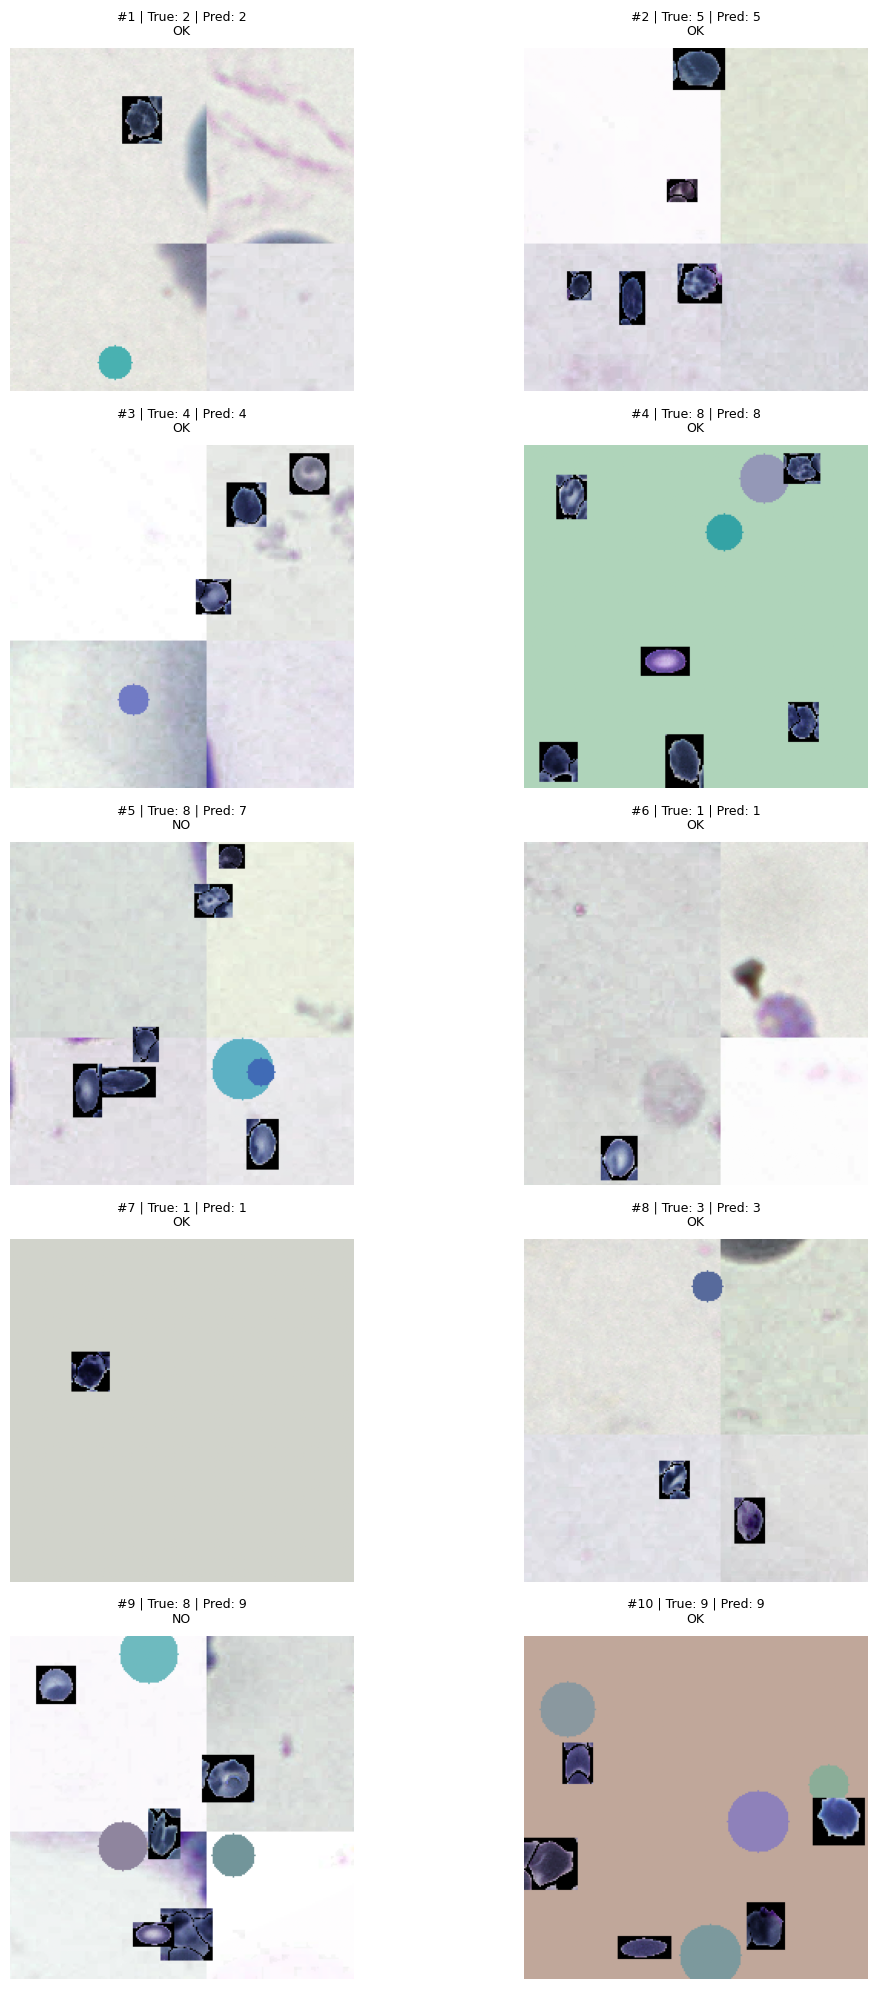


Сводная статистика:
Accuracy: 80%
MAE: 0.20


In [55]:
model.eval()

results = []

with torch.no_grad():
    for i in range(10):
        img, target, true_c = dataset[random.randint(0, len(train_dataset))]
        logits = model(img.unsqueeze(0).to(DEVICE))
        probs = torch.softmax(logits, dim=1)[0]
        
        pred_class = torch.argmax(probs).item()
        pred_smooth = (probs * torch.arange(MAX_CELLS+1, device=DEVICE)).sum().item()
        
        print(f"True: {true_c:2d} | Pred: {pred_class:2d}")
        results.append((img, target, true_c, pred_class, pred_smooth, probs.cpu()))

fig, axes = plt.subplots(5, 2, figsize=(12, 20))

for i in range(10):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    img, target, true_c, pred_class, pred_smooth, probs = results[i]
    
    img_d = img.clone()
    img_d = img_d * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img_d = np.clip(img_d.numpy().transpose(1,2,0), 0, 1)
    
    ax.imshow(img_d)
    error = abs(pred_class - true_c)
    ax.set_title(f"#{i+1} | True: {true_c} | Pred: {pred_class}\n{'OK' if error <= 0 else 'NO'}", 
                 fontsize=9, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nСводная статистика:")
accuracies = [abs(results[i][2] - results[i][3]) <= 0 for i in range(10)]
mae = sum([abs(results[i][2] - results[i][3]) for i in range(10)]) / 10
print(f"Accuracy: {sum(accuracies)/10*100:.0f}%")
print(f"MAE: {mae:.2f}")